In [4]:
import os
import cv2
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve, auc
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

print("✅ All imports successful!")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

✅ All imports successful!
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
train_path = "/kaggle/input/datasets/luumsk/asnr-miccai-brats-2023-gli-challenge-training-data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

patients = sorted(os.listdir(train_path))
print("Total Patients:", len(patients))

train_patients, temp_patients = train_test_split(
    patients, test_size=0.19, random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.53, random_state=42
)

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Total Patients: 1251
Train: 1013
Validation: 111
Test: 127


In [6]:
class BraTSDataset(Dataset):

    def __init__(self, patient_list, root_dir, image_size=128):
        self.samples = []
        self.root_dir = root_dir
        self.image_size = image_size
        views = ['axial', 'sagittal', 'coronal']

        for patient in patient_list:
            patient_path = os.path.join(root_dir, patient)
            t1c_path   = os.path.join(patient_path, f"{patient}-t1c.nii")
            flair_path = os.path.join(patient_path, f"{patient}-t2f.nii")
            seg_path   = os.path.join(patient_path, f"{patient}-seg.nii")
            for view in views:
                self.samples.append((t1c_path, flair_path, seg_path, view))

        print("Total sample entries:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        t1c_path, flair_path, seg_path, view = self.samples[idx]

        try:
            t1c   = nib.load(t1c_path).get_fdata()
            flair = nib.load(flair_path).get_fdata()
            seg   = nib.load(seg_path).get_fdata()
        except:
            return torch.zeros((2, 128, 128)), torch.zeros((1, 128, 128))

        t1c   = (t1c   - t1c.min())   / (t1c.max()   - t1c.min()   + 1e-8)
        flair = (flair - flair.min()) / (flair.max() - flair.min() + 1e-8)
        seg   = (seg > 0).astype(np.float32)

        if view == 'axial':
            i = t1c.shape[0] // 2
            t1c_s, flair_s, mask_s = t1c[i,:,:], flair[i,:,:], seg[i,:,:]
        elif view == 'sagittal':
            i = t1c.shape[1] // 2
            t1c_s, flair_s, mask_s = t1c[:,i,:], flair[:,i,:], seg[:,i,:]
        else:
            i = t1c.shape[2] // 2
            t1c_s, flair_s, mask_s = t1c[:,:,i], flair[:,:,i], seg[:,:,i]

        t1c_s   = cv2.resize(t1c_s,   (self.image_size, self.image_size))
        flair_s = cv2.resize(flair_s, (self.image_size, self.image_size))
        mask_s  = cv2.resize(mask_s,  (self.image_size, self.image_size))

        image = np.stack([t1c_s, flair_s], axis=0)
        image = torch.tensor(image, dtype=torch.float32)
        mask  = torch.tensor(mask_s, dtype=torch.float32).unsqueeze(0)

        return image, mask

print("✅ Dataset class defined!")

✅ Dataset class defined!


In [7]:
train_dataset = BraTSDataset(train_patients, train_path)
val_dataset   = BraTSDataset(val_patients,   train_path)
test_dataset  = BraTSDataset(test_patients,  train_path)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False, num_workers=0, pin_memory=False)

print("Train batches    :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches     :", len(test_loader))

Total sample entries: 3039
Total sample entries: 333
Total sample entries: 381
Train batches    : 1520
Validation batches: 167
Test batches     : 191


In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class GlobalBranch(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class DualBranchUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1  = DoubleConv(2, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.global1 = GlobalBranch(32)
        self.global2 = GlobalBranch(64)
        self.global3 = GlobalBranch(128)
        self.bottleneck = DoubleConv(128, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)
        self.dropout  = nn.Dropout2d(0.3)

    def forward(self, x):
        e1 = self.global1(self.enc1(x));  p1 = self.pool1(e1)
        e2 = self.global2(self.enc2(p1)); p2 = self.pool2(e2)
        e3 = self.global3(self.enc3(p2)); p3 = self.pool3(e3)
        b  = self.dropout(self.bottleneck(p3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

print("✅ Model architecture defined!")

✅ Model architecture defined!


In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)
        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

bce_loss_fn  = nn.BCEWithLogitsLoss()
dice_loss_fn = DiceLoss()

def combined_loss(preds, targets):
    return bce_loss_fn(preds, targets) + dice_loss_fn(preds, targets)

print("✅ Loss functions defined!")

✅ Loss functions defined!


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = DualBranchUNet().to(device)

import glob
paths = glob.glob("/kaggle/input/**/dual_branch_epoch_50.pth", recursive=True)
print("Found:", paths)

checkpoint_path = paths[0] if paths else None

if checkpoint_path:
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"✅ Loaded: {checkpoint_path}")
else:
    print("❌ Checkpoint not found!")

optimizer = optim.Adam(model.parameters(), lr=1e-4)
print("✅ Optimizer ready!")

Device: cuda
Found: ['/kaggle/input/models/uditarath/brain-tumor-epoch50/pytorch/default/1/dual_branch_epoch_50.pth']
✅ Loaded: /kaggle/input/models/uditarath/brain-tumor-epoch50/pytorch/default/1/dual_branch_epoch_50.pth
✅ Optimizer ready!


In [11]:
model.eval()
dice_scores = []
iou_scores  = []
all_preds   = []
all_targets = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Final Evaluation"):
        images  = images.to(device)
        masks   = masks.to(device)
        outputs = model(images)
        probs   = torch.sigmoid(outputs)
        preds   = (probs > 0.3).float()

        for j in range(masks.shape[0]):
            mask_j = masks[j].view(-1).cpu().numpy()
            pred_j = preds[j].view(-1).cpu().numpy()
            prob_j = probs[j].view(-1).cpu().numpy()

            if mask_j.sum() > 0:
                intersection = (pred_j * mask_j).sum()
                dice = (2. * intersection + 1e-8) / (pred_j.sum() + mask_j.sum() + 1e-8)
                union = pred_j.sum() + mask_j.sum() - intersection
                iou  = (intersection + 1e-8) / (union + 1e-8)
                dice_scores.append(dice)
                iou_scores.append(iou)

            all_preds.extend(prob_j)
            all_targets.extend(mask_j)

all_preds      = np.array(all_preds)
all_targets    = np.array(all_targets)
binary_preds   = (all_preds > 0.3).astype(np.uint8)
binary_targets = (all_targets > 0.5).astype(np.uint8)

print("\n===== FINAL TEST RESULTS (Epoch 50) =====")
print(f"Dice Score : {np.mean(dice_scores):.4f}")
print(f"IoU Score  : {np.mean(iou_scores):.4f}")
print(f"Precision  : {precision_score(binary_targets, binary_preds, zero_division=0):.4f}")
print(f"Recall     : {recall_score(binary_targets, binary_preds, zero_division=0):.4f}")
print(f"ROC-AUC    : {roc_auc_score(binary_targets, all_preds):.4f}")

Final Evaluation: 100%|██████████| 191/191 [01:43<00:00,  1.85it/s]



===== FINAL TEST RESULTS (Epoch 50) =====
Dice Score : 0.6573
IoU Score  : 0.5703
Precision  : 0.3712
Recall     : 0.8723
ROC-AUC    : 0.9856


In [12]:
# Quick threshold comparison
print("=== Threshold Comparison ===")
for threshold in [0.3, 0.4, 0.5, 0.6]:
    binary_preds_t = (all_preds > threshold).astype(np.uint8)
    p = precision_score(binary_targets, binary_preds_t, zero_division=0)
    r = recall_score(binary_targets, binary_preds_t, zero_division=0)
    
    # Dice
    dice_t = []
    for i in range(0, len(all_preds), 128*128):
        pred_chunk = (all_preds[i:i+128*128] > threshold).astype(np.float32)
        mask_chunk = binary_targets[i:i+128*128].astype(np.float32)
        if mask_chunk.sum() > 0:
            intersection = (pred_chunk * mask_chunk).sum()
            dice = (2. * intersection + 1e-8) / (pred_chunk.sum() + mask_chunk.sum() + 1e-8)
            dice_t.append(dice)
    
    print(f"Threshold {threshold} → Dice: {np.mean(dice_t):.4f} | Precision: {p:.4f} | Recall: {r:.4f}")

=== Threshold Comparison ===
Threshold 0.3 → Dice: 0.6597 | Precision: 0.3712 | Recall: 0.8723
Threshold 0.4 → Dice: 0.6592 | Precision: 0.3734 | Recall: 0.8667
Threshold 0.5 → Dice: 0.6585 | Precision: 0.3755 | Recall: 0.8614
Threshold 0.6 → Dice: 0.6583 | Precision: 0.3774 | Recall: 0.8558


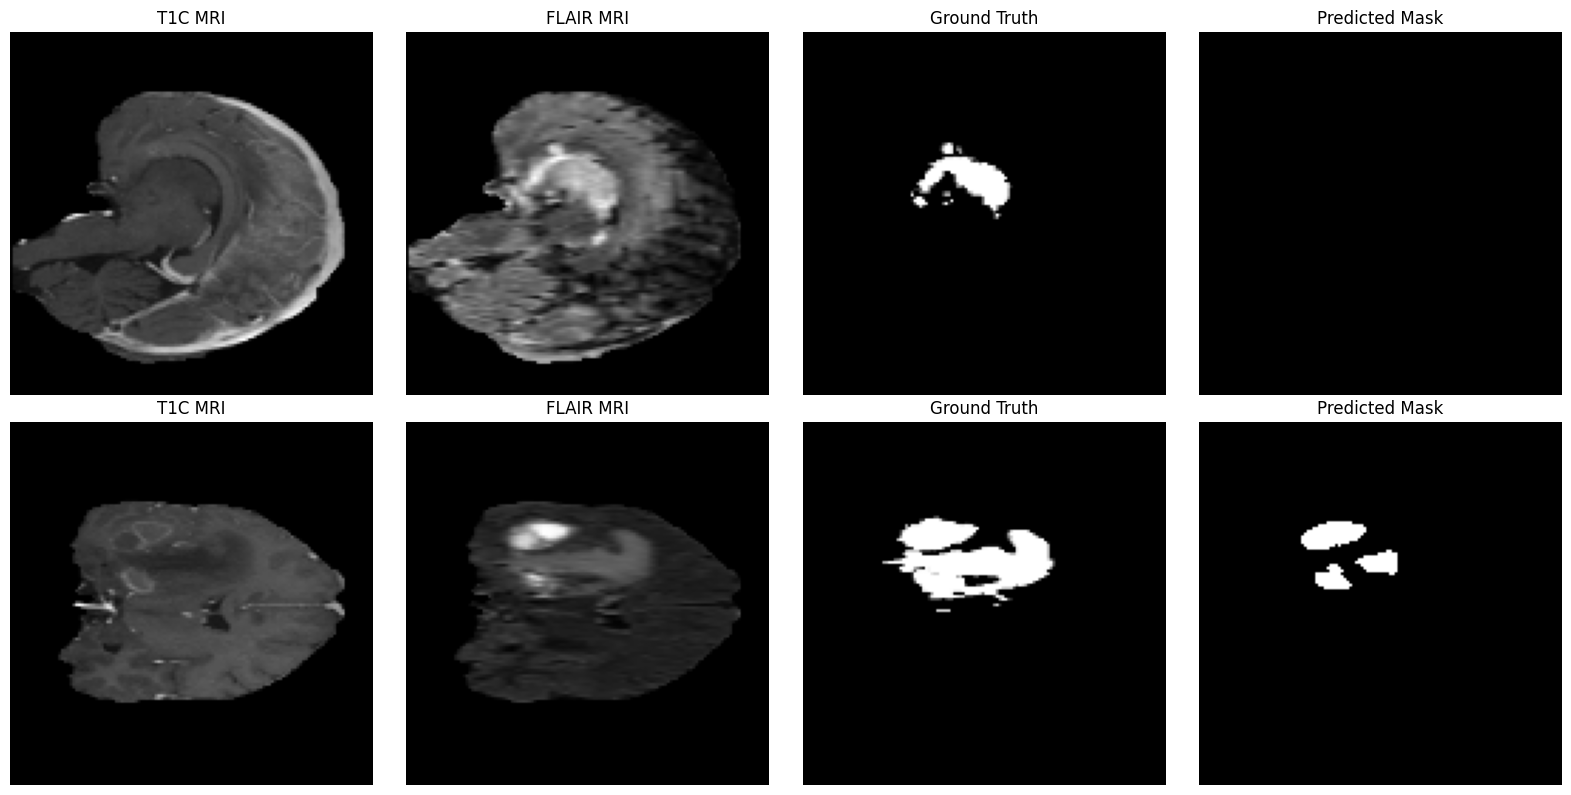

✅ Visualization saved!


In [13]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    probs   = torch.sigmoid(outputs)
    preds   = (probs > 0.5).float()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(2):
    image = images[i].cpu().numpy()
    mask  = masks[i].squeeze().cpu().numpy()
    pred  = preds[i].squeeze().cpu().numpy()

    axes[i,0].imshow(image[0], cmap='gray')
    axes[i,0].set_title("T1C MRI")
    axes[i,0].axis('off')

    axes[i,1].imshow(image[1], cmap='gray')
    axes[i,1].set_title("FLAIR MRI")
    axes[i,1].axis('off')

    axes[i,2].imshow(mask, cmap='gray')
    axes[i,2].set_title("Ground Truth")
    axes[i,2].axis('off')

    axes[i,3].imshow(pred, cmap='gray')
    axes[i,3].set_title("Predicted Mask")
    axes[i,3].axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/prediction_visualization.png", dpi=150)
plt.show()
print("✅ Visualization saved!")

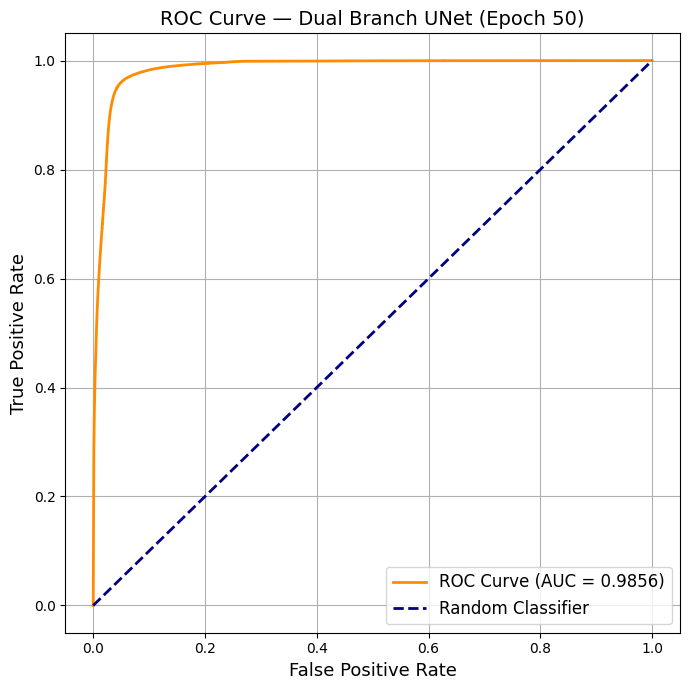

✅ ROC Curve saved!


In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(binary_targets, all_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ROC Curve — Dual Branch UNet (Epoch 50)", fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150)
plt.show()
print("✅ ROC Curve saved!")

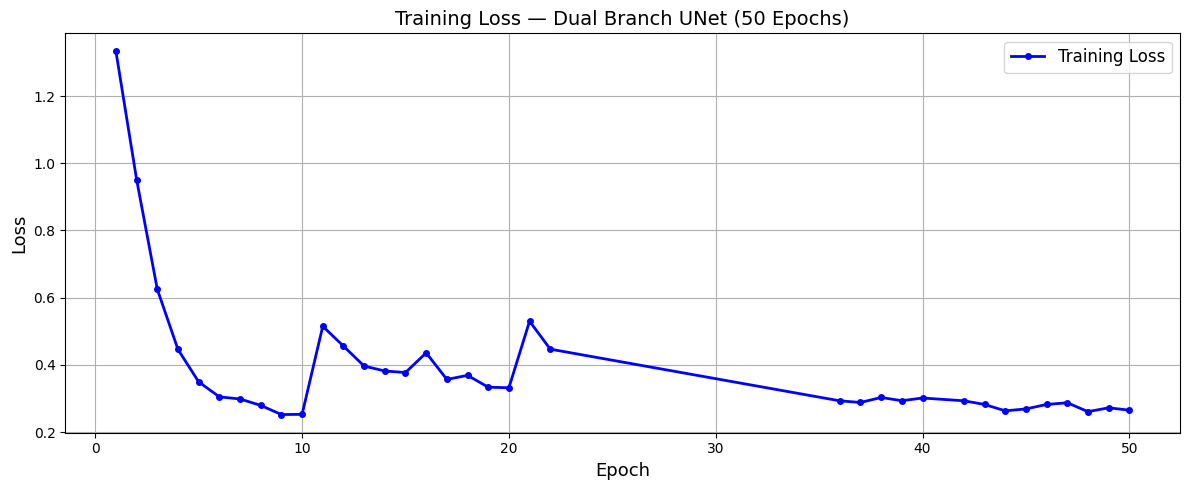

✅ Training loss plot saved!


In [15]:
epochs_all = [1,2,3,4,5,6,7,8,9,10,
               11,12,13,14,15,16,17,18,19,20,
               21,22,36,37,38,39,40,42,43,44,
               45,46,47,48,49,50]

losses_all = [1.3326,0.9511,0.6247,0.4457,0.3493,0.3047,0.2984,0.2793,0.2520,0.2527,
              0.5147,0.4558,0.3964,0.3817,0.3771,0.4357,0.3566,0.3687,0.3335,0.3318,
              0.5298,0.4467,0.2929,0.2880,0.3029,0.2932,0.3013,0.2930,0.2821,0.2631,
              0.2688,0.2821,0.2871,0.2607,0.2721,0.2651]

plt.figure(figsize=(12, 5))
plt.plot(epochs_all, losses_all, color='blue', linewidth=2, marker='o', markersize=4, label='Training Loss')
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)
plt.title("Training Loss — Dual Branch UNet (50 Epochs)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/training_loss_plot.png", dpi=150)
plt.show()
print("✅ Training loss plot saved!")

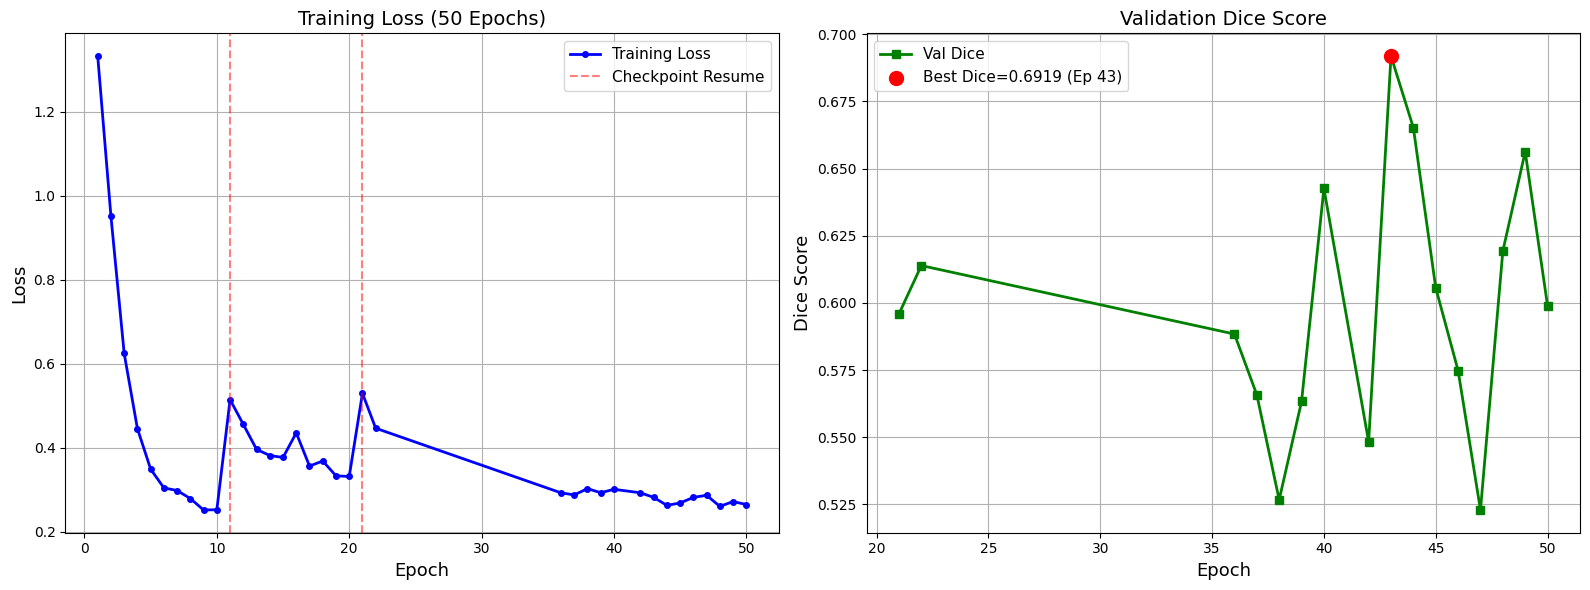

✅ Figure 1 saved!


In [16]:
epochs_all = [1,2,3,4,5,6,7,8,9,10,
               11,12,13,14,15,16,17,18,19,20,
               21,22,36,37,38,39,40,42,43,44,
               45,46,47,48,49,50]

losses_all = [1.3326,0.9511,0.6247,0.4457,0.3493,0.3047,0.2984,0.2793,0.2520,0.2527,
              0.5147,0.4558,0.3964,0.3817,0.3771,0.4357,0.3566,0.3687,0.3335,0.3318,
              0.5298,0.4467,0.2929,0.2880,0.3029,0.2932,0.3013,0.2930,0.2821,0.2631,
              0.2688,0.2821,0.2871,0.2607,0.2721,0.2651]

val_epochs = [21, 22, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 50]
val_dices  = [0.5959, 0.6139, 0.5884, 0.5658, 0.5267, 0.5633, 0.6426, 0.5483,
              0.6919, 0.6652, 0.6056, 0.5748, 0.5229, 0.6193, 0.6563, 0.5989]

best_epoch = val_epochs[val_dices.index(max(val_dices))]
best_dice  = max(val_dices)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Training Loss
axes[0].plot(epochs_all, losses_all, color='blue', linewidth=2, marker='o', markersize=4, label='Training Loss')
axes[0].axvline(x=11, color='red', linestyle='--', alpha=0.5, label='Checkpoint Resume')
axes[0].axvline(x=21, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel("Epoch", fontsize=13)
axes[0].set_ylabel("Loss", fontsize=13)
axes[0].set_title("Training Loss (50 Epochs)", fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True)

# Right — Validation Dice
axes[1].plot(val_epochs, val_dices, color='green', linewidth=2, marker='s', markersize=6, label='Val Dice')
axes[1].scatter([best_epoch], [best_dice], color='red', zorder=5, s=100, label=f'Best Dice={best_dice:.4f} (Ep {best_epoch})')
axes[1].set_xlabel("Epoch", fontsize=13)
axes[1].set_ylabel("Dice Score", fontsize=13)
axes[1].set_title("Validation Dice Score", fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/figure1_training_curves.png", dpi=150)
plt.show()
print("✅ Figure 1 saved!")

/tmp/ipykernel_57/2723670934.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


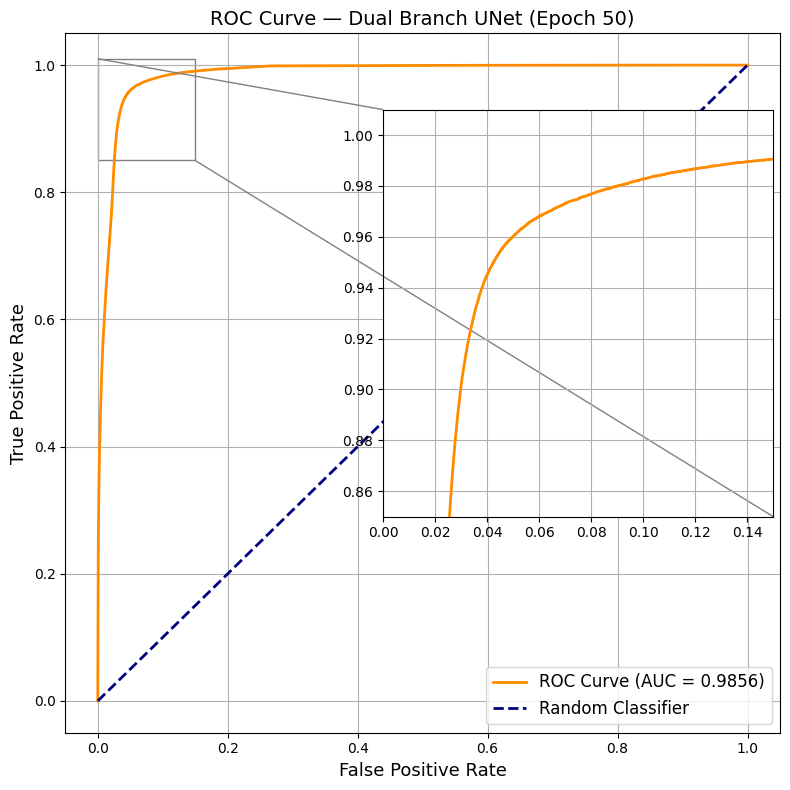

✅ Figure 3 saved!


In [17]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

fpr, tpr, _ = roc_curve(binary_targets, all_preds)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0,1], [0,1], color='navy', linewidth=2, linestyle='--', label='Random Classifier')
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curve — Dual Branch UNet (Epoch 50)", fontsize=14)
ax.legend(loc="lower right", fontsize=12)
ax.grid(True)

# Zoomed inset top-left
axins = zoomed_inset_axes(ax, zoom=4, loc='center right',
                           bbox_to_anchor=(0.6, 0.4, 0.4, 0.4),
                           bbox_transform=ax.transAxes)
axins.plot(fpr, tpr, color='darkorange', linewidth=2)
axins.set_xlim(0, 0.15)
axins.set_ylim(0.85, 1.01)
axins.grid(True)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.savefig("/kaggle/working/figure3_roc_curve.png", dpi=150)
plt.show()
print("✅ Figure 3 saved!")


/tmp/ipykernel_57/880870494.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/880870494.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/880870494.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/880870494.py:62: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/figure4_qualitative.png", dpi=150)
/tmp/ipykernel_57/880870494.py:62: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/figure4_qualitative.png", dpi=150)
/tmp/ipykernel_57/880870494.py:62: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/figure4_qualitative.png", dpi=150)
/usr/local/lib/python

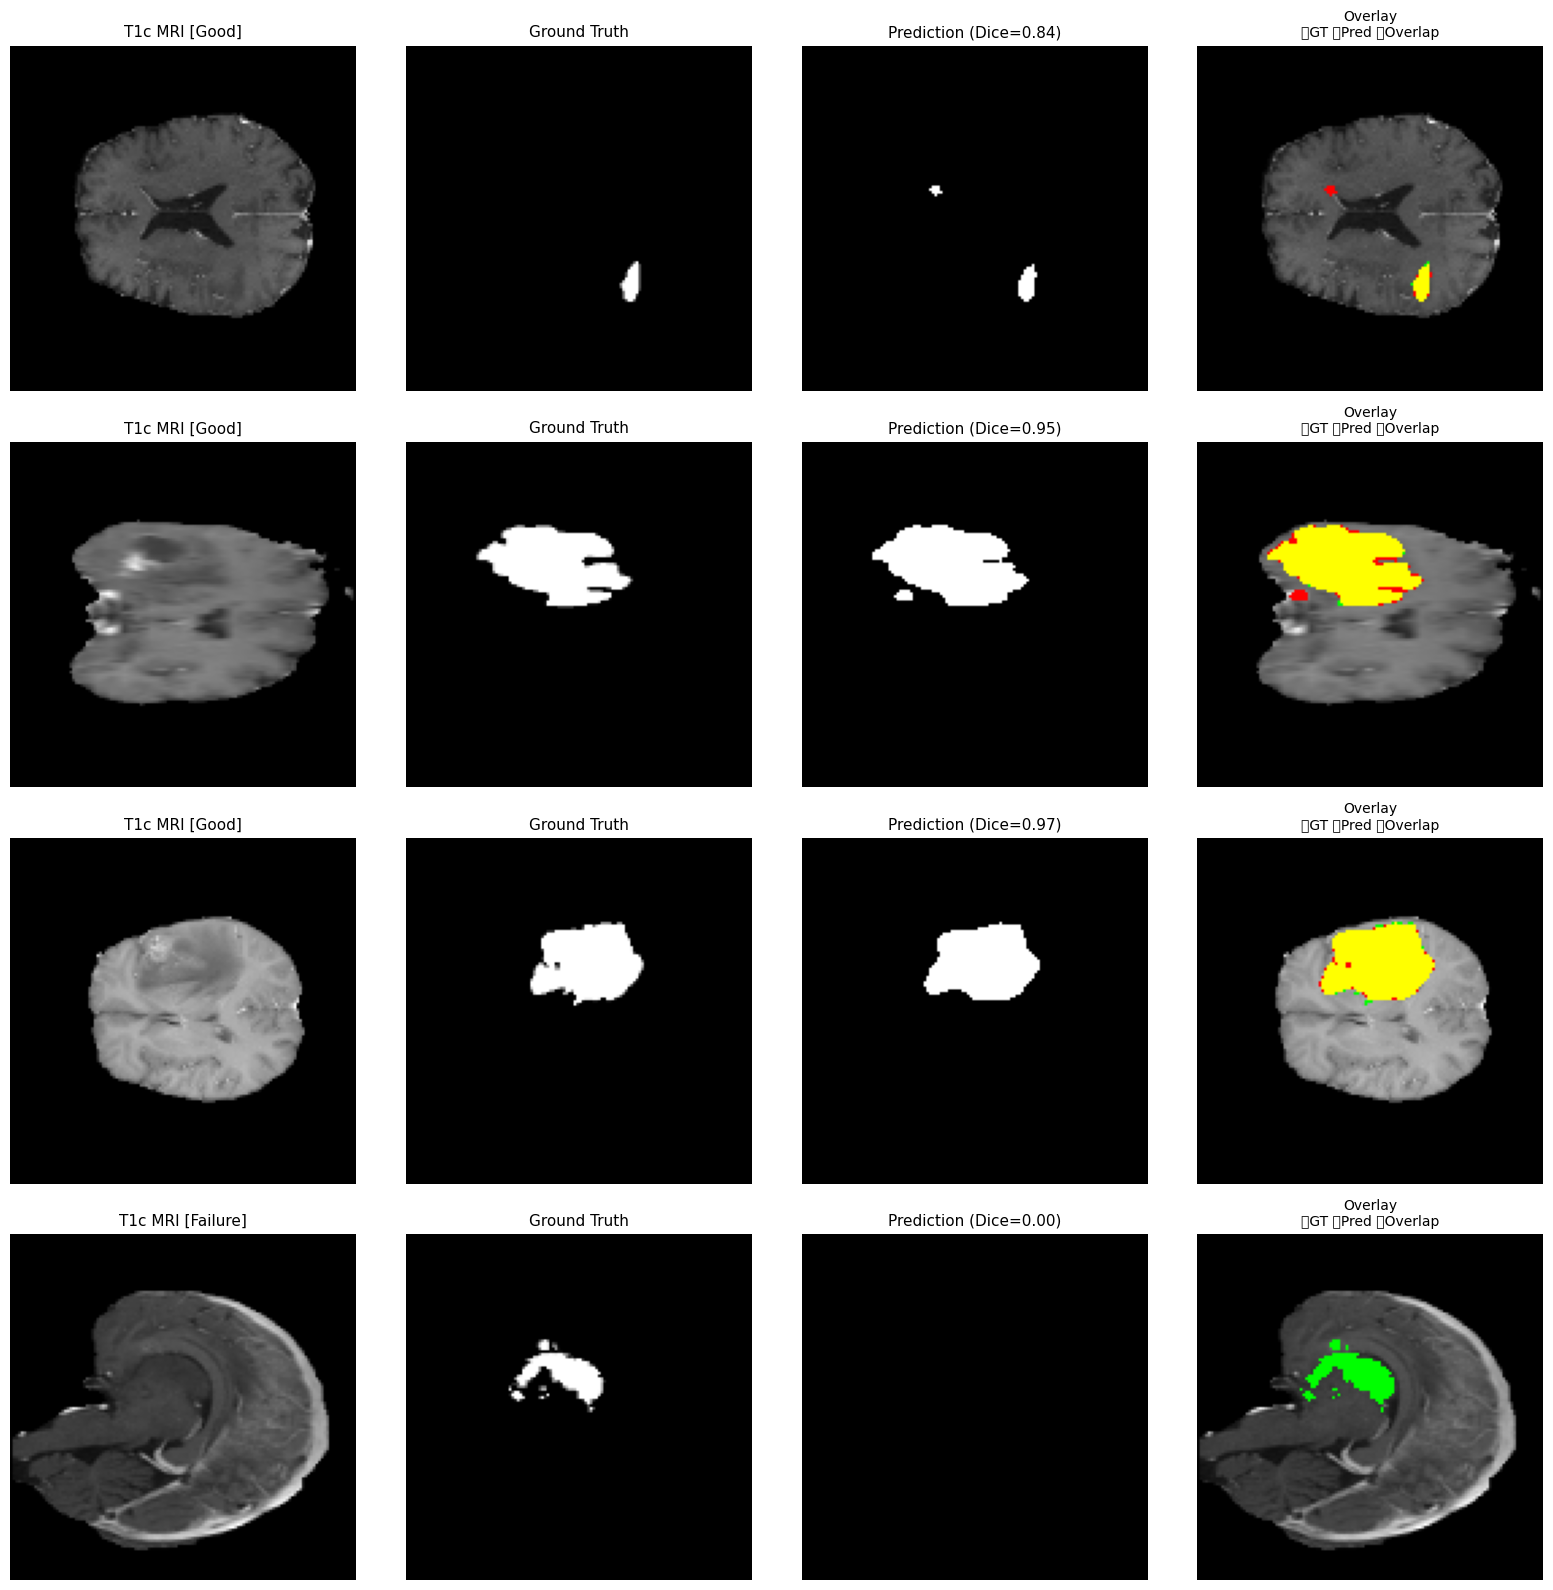

✅ Figure 4 saved!


In [18]:
model.eval()
good_samples = []
fail_samples = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        for j in range(masks.shape[0]):
            mask_j = masks[j].squeeze().cpu().numpy()
            pred_j = preds[j].squeeze().cpu().numpy()
            img_j  = images[j].cpu().numpy()

            if mask_j.sum() > 0:
                intersection = (pred_j * mask_j).sum()
                dice = (2.*intersection+1e-8)/(pred_j.sum()+mask_j.sum()+1e-8)

                if dice > 0.6 and len(good_samples) < 3:
                    good_samples.append((img_j, mask_j, pred_j, dice))
                elif dice < 0.2 and len(fail_samples) < 1:
                    fail_samples.append((img_j, mask_j, pred_j, dice))

        if len(good_samples) >= 3 and len(fail_samples) >= 1:
            break

all_samples = good_samples + fail_samples
labels = ['Good', 'Good', 'Good', 'Failure']

fig, axes = plt.subplots(len(all_samples), 4, figsize=(16, 4*len(all_samples)))

for i, (img, mask, pred, dice) in enumerate(all_samples):
    # T1c
    axes[i,0].imshow(img[0], cmap='gray')
    axes[i,0].set_title(f"T1c MRI [{labels[i]}]", fontsize=11)
    axes[i,0].axis('off')

    # Ground Truth
    axes[i,1].imshow(mask, cmap='gray')
    axes[i,1].set_title("Ground Truth", fontsize=11)
    axes[i,1].axis('off')

    # Prediction
    axes[i,2].imshow(pred, cmap='gray')
    axes[i,2].set_title(f"Prediction (Dice={dice:.2f})", fontsize=11)
    axes[i,2].axis('off')

    # Overlay
    overlay = np.stack([img[0]]*3, axis=-1)
    overlay = (overlay - overlay.min()) / (overlay.max() - overlay.min() + 1e-8)
    overlay[mask > 0.5] = [0, 1, 0]   # green = ground truth
    overlay[pred > 0.5] = [1, 0, 0]   # red   = prediction
    overlap = (mask > 0.5) & (pred > 0.5)
    overlay[overlap] = [1, 1, 0]       # yellow = overlap
    axes[i,3].imshow(overlay)
    axes[i,3].set_title("Overlay\n🟢GT 🔴Pred 🟡Overlap", fontsize=10)
    axes[i,3].axis('off')

plt.tight_layout()
plt.savefig("/kaggle/working/figure4_qualitative.png", dpi=150)
plt.show()
print("✅ Figure 4 saved!")

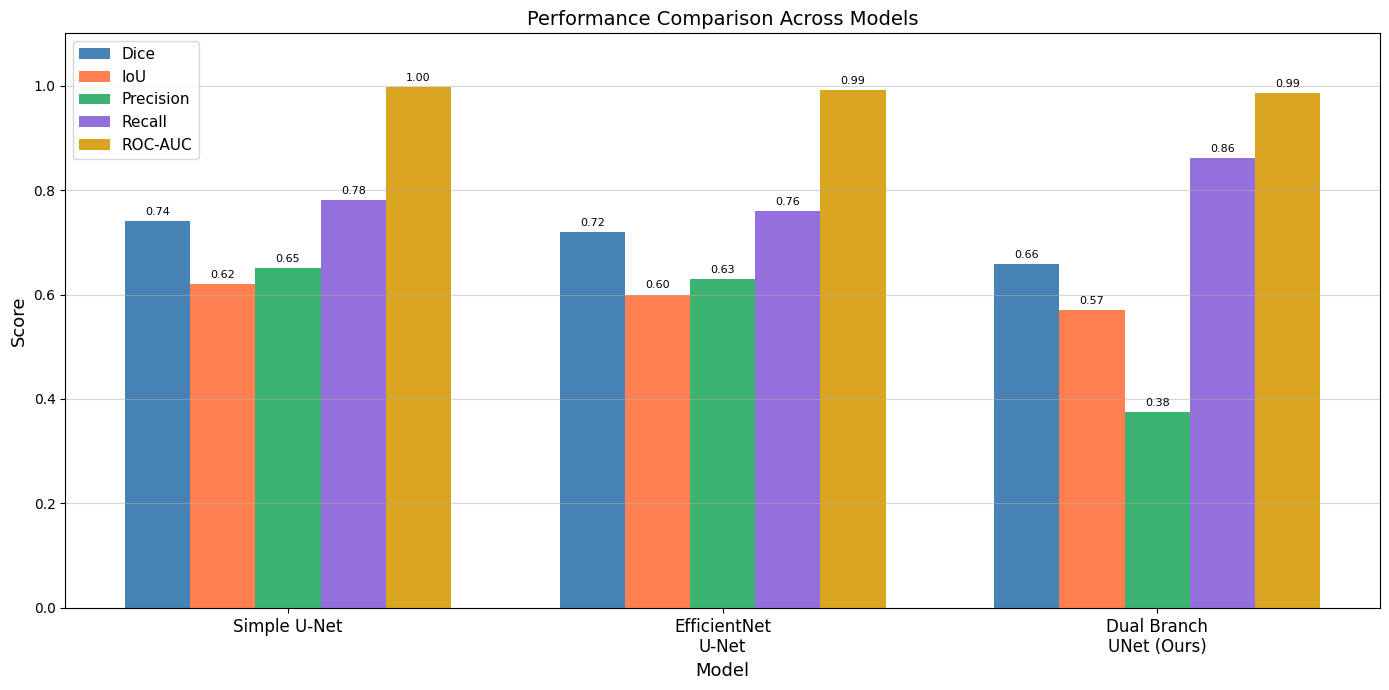

✅ Figure 5 saved!


In [19]:
models = ['Simple U-Net', 'EfficientNet\nU-Net', 'Dual Branch\nUNet (Ours)']

# Results from your project history
dice      = [0.74,  0.72,  0.6585]
iou       = [0.62,  0.60,  0.5703]
precision = [0.65,  0.63,  0.3755]
recall    = [0.78,  0.76,  0.8614]
auc_vals  = [0.997, 0.991, 0.9856]

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

b1 = ax.bar(x - 2*width, dice,      width, label='Dice',      color='steelblue')
b2 = ax.bar(x - width,   iou,       width, label='IoU',       color='coral')
b3 = ax.bar(x,           precision, width, label='Precision',  color='mediumseagreen')
b4 = ax.bar(x + width,   recall,    width, label='Recall',     color='mediumpurple')
b5 = ax.bar(x + 2*width, auc_vals,  width, label='ROC-AUC',   color='goldenrod')

ax.set_xlabel("Model", fontsize=13)
ax.set_ylabel("Score", fontsize=13)
ax.set_title("Performance Comparison Across Models", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.5)

# Add value labels on bars
for bars in [b1, b2, b3, b4, b5]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/figure5_comparison.png", dpi=150)
plt.show()
print("✅ Figure 5 saved!")

In [21]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

import numpy as np
import torch
from tqdm import tqdm

# ==========================================
# FINAL EVALUATION
# ==========================================

model.eval()

dice_scores = []
iou_scores  = []

all_preds   = []
all_targets = []

with torch.no_grad():

    for images, masks in tqdm(
        test_loader,
        desc="Final Evaluation"
    ):

        # Move to GPU
        images = images.to(device)
        masks  = masks.to(device)

        # Model prediction
        outputs = model(images)

        # Convert logits -> probabilities
        probs = torch.sigmoid(outputs)

        # Binary prediction mask
        preds = (probs > 0.3).float()

        # =====================================
        # PER-IMAGE METRICS
        # =====================================

        for j in range(masks.shape[0]):

            mask_j = masks[j].view(-1).cpu().numpy()

            pred_j = preds[j].view(-1).cpu().numpy()

            prob_j = probs[j].view(-1).cpu().numpy()

            # Ignore completely empty masks
            if mask_j.sum() > 0:

                # Dice Score
                intersection = (
                    pred_j * mask_j
                ).sum()

                dice = (
                    2. * intersection + 1e-8
                ) / (
                    pred_j.sum()
                    + mask_j.sum()
                    + 1e-8
                )

                dice_scores.append(dice)

                # IoU Score
                union = (
                    pred_j.sum()
                    + mask_j.sum()
                    - intersection
                )

                iou = (
                    intersection + 1e-8
                ) / (
                    union + 1e-8
                )

                iou_scores.append(iou)

            # Store predictions
            all_preds.extend(prob_j)

            all_targets.extend(mask_j)

# ==========================================
# CONVERT TO NUMPY
# ==========================================

all_preds   = np.array(all_preds)

all_targets = np.array(all_targets)

# Binary conversion
binary_preds = (
    all_preds > 0.3
).astype(np.uint8)

binary_targets = (
    all_targets > 0.5
).astype(np.uint8)

# ==========================================
# CLASSIFICATION METRICS
# ==========================================

precision = precision_score(
    binary_targets,
    binary_preds,
    zero_division=0
)

recall = recall_score(
    binary_targets,
    binary_preds,
    zero_division=0
)

f1 = f1_score(
    binary_targets,
    binary_preds,
    zero_division=0
)

accuracy = accuracy_score(
    binary_targets,
    binary_preds
)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(
    binary_targets,
    binary_preds
).ravel()

# Specificity
specificity = tn / (
    tn + fp + 1e-8
)

# Sensitivity
sensitivity = recall

# ROC-AUC
auc_score = roc_auc_score(
    binary_targets,
    all_preds
)

# ==========================================
# FINAL RESULTS
# ==========================================

print("\n========== FINAL TEST RESULTS ==========\n")

print(f"Average Dice Score : {np.mean(dice_scores):.4f}")

print(f"Average IoU Score  : {np.mean(iou_scores):.4f}")

print(f"Precision          : {precision:.4f}")

print(f"Recall             : {recall:.4f}")

print(f"F1 Score           : {f1:.4f}")

print(f"Accuracy           : {accuracy:.4f}")

print(f"Specificity        : {specificity:.4f}")

print(f"Sensitivity        : {sensitivity:.4f}")

print(f"ROC-AUC Score      : {auc_score:.4f}")

print("\n========================================")

Final Evaluation: 100%|██████████| 191/191 [01:01<00:00,  3.13it/s]



========== FINAL TEST RESULTS ==========

Average Dice Score : 0.6573
Average IoU Score  : 0.5703
Precision          : 0.3712
Recall             : 0.8723
F1 Score           : 0.5208
Accuracy           : 0.9711
Specificity        : 0.9729
Sensitivity        : 0.8723
ROC-AUC Score      : 0.9856



Found 4 good samples!


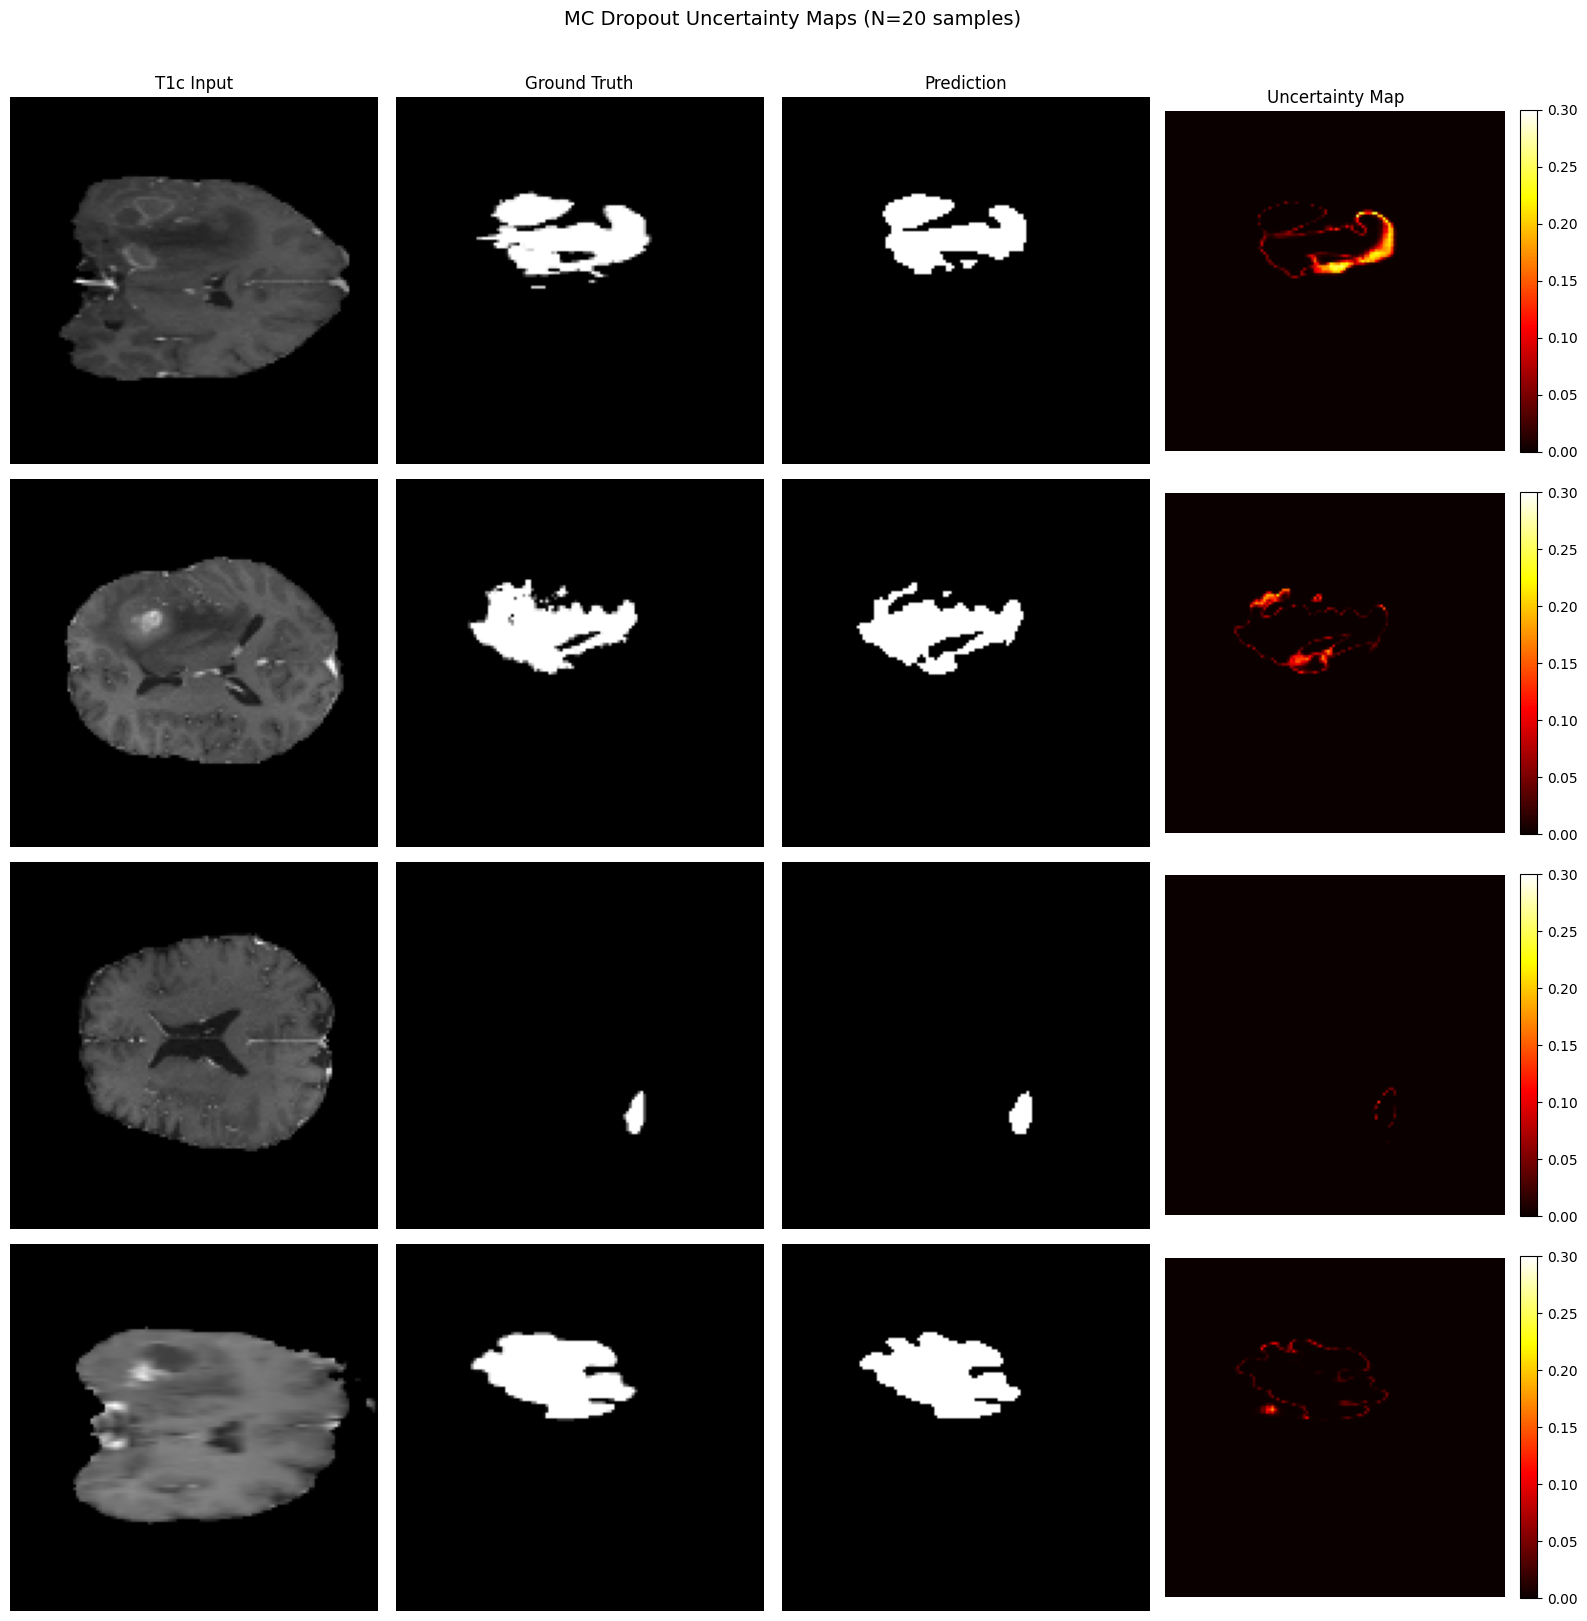

✅ Figure 2 saved!


In [22]:
# MC Dropout Uncertainty Estimation
def mc_dropout_predict(model, image, n_samples=20):
    model.train()  # keep dropout active
    predictions = []
    
    with torch.no_grad():
        for _ in range(n_samples):
            output = model(image)
            prob   = torch.sigmoid(output)
            predictions.append(prob.cpu().numpy())
    
    predictions = np.array(predictions)  # shape: (n_samples, B, 1, H, W)
    mean_pred   = predictions.mean(axis=0)
    uncertainty = predictions.std(axis=0)  # std = uncertainty
    
    return mean_pred, uncertainty

# Find good samples with tumor
model.eval()
good_samples = []

with torch.no_grad():
    for images, masks in test_loader:
        images_gpu = images.to(device)
        outputs    = model(images_gpu)
        probs      = torch.sigmoid(outputs)
        preds      = (probs > 0.5).float()

        for j in range(masks.shape[0]):
            mask_j = masks[j].squeeze().cpu().numpy()
            pred_j = preds[j].squeeze().cpu().numpy()

            if mask_j.sum() > 0:
                intersection = (pred_j * mask_j).sum()
                dice = (2.*intersection+1e-8)/(pred_j.sum()+mask_j.sum()+1e-8)
                if dice > 0.5 and len(good_samples) < 4:
                    good_samples.append((images[j:j+1], masks[j], dice))

        if len(good_samples) >= 4:
            break

print(f"Found {len(good_samples)} good samples!")

# Generate uncertainty maps
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
col_titles = ["T1c Input", "Ground Truth", "Prediction", "Uncertainty Map"]

for i, (img_tensor, mask, dice) in enumerate(good_samples):
    img_gpu = img_tensor.to(device)
    
    # MC Dropout predictions
    mean_pred, uncertainty = mc_dropout_predict(model, img_gpu, n_samples=20)
    
    mean_pred_sq   = mean_pred[0, 0]      # H x W
    uncertainty_sq = uncertainty[0, 0]    # H x W
    final_pred     = (mean_pred_sq > 0.5).astype(np.float32)
    mask_np        = mask.squeeze().cpu().numpy()
    img_np         = img_tensor[0].cpu().numpy()

    # T1c Input
    axes[i,0].imshow(img_np[0], cmap='gray')
    axes[i,0].set_title(col_titles[0] if i==0 else "", fontsize=12)
    axes[i,0].set_ylabel(f"Sample {i+1}\nDice={dice:.2f}", fontsize=10)
    axes[i,0].axis('off')

    # Ground Truth
    axes[i,1].imshow(mask_np, cmap='gray')
    axes[i,1].set_title(col_titles[1] if i==0 else "", fontsize=12)
    axes[i,1].axis('off')

    # Prediction
    axes[i,2].imshow(final_pred, cmap='gray')
    axes[i,2].set_title(col_titles[2] if i==0 else "", fontsize=12)
    axes[i,2].axis('off')

    # Uncertainty Map
    unc_plot = axes[i,3].imshow(uncertainty_sq, cmap='hot', vmin=0, vmax=0.3)
    axes[i,3].set_title(col_titles[3] if i==0 else "", fontsize=12)
    axes[i,3].axis('off')
    plt.colorbar(unc_plot, ax=axes[i,3], fraction=0.046, pad=0.04)

plt.suptitle("MC Dropout Uncertainty Maps (N=20 samples)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/figure2_uncertainty_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved!")

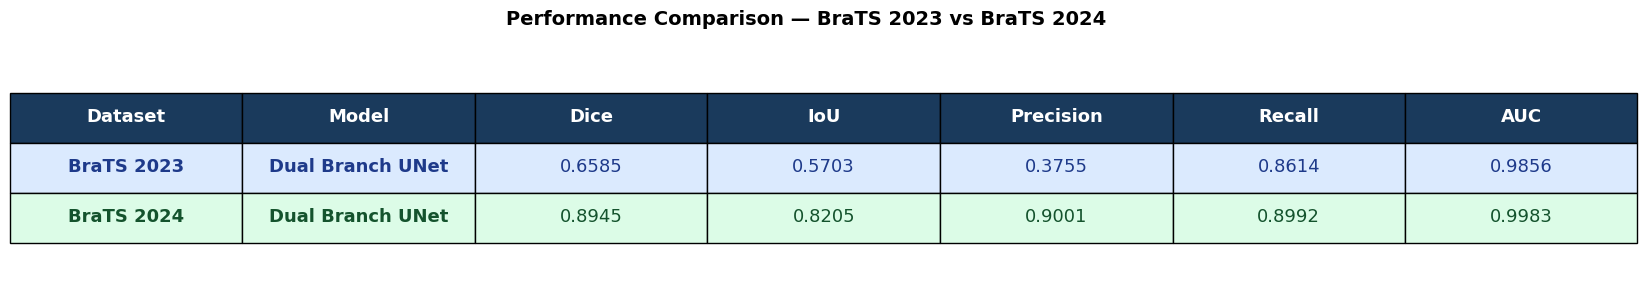

✅ Comparison table saved!


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

columns = ['Dataset', 'Model', 'Dice', 'IoU', 'Precision', 'Recall', 'AUC']
rows = [
    ['BraTS 2023', 'Dual Branch UNet', '0.6585', '0.5703', '0.3755', '0.8614', '0.9856'],
    ['BraTS 2024', 'Dual Branch UNet', '0.8945', '0.8205', '0.9001', '0.8992', '0.9983'],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.5, 3)

# Header
for j in range(len(columns)):
    table[0, j].set_facecolor('#1a3a5c')
    table[0, j].set_text_props(color='white', fontweight='bold')

# BraTS 2023 row — blue
for j in range(len(columns)):
    table[1, j].set_facecolor('#dbeafe')
    table[1, j].set_text_props(color='#1e3a8a', fontweight='bold' if j in [0,1] else 'normal')

# BraTS 2024 row — green
for j in range(len(columns)):
    table[2, j].set_facecolor('#dcfce7')
    table[2, j].set_text_props(color='#14532d', fontweight='bold' if j in [0,1] else 'normal')

plt.suptitle("Performance Comparison — BraTS 2023 vs BraTS 2024",
             fontsize=14, fontweight='bold', y=1.02)

plt.savefig("/kaggle/working/comparison_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison table saved!")